In [ ]:
import numpy as np
import pandas as pd 
import math 
from vpython import *
#time = 0.01
#G = 6.674 * math.pow(10,-11)
'''
    def Acceleration(self):
         self.a[0] = self.f[0]/self.m
         self.a[1] = self.f[1]/self.m
         self.a[2] = self.f[2]/self.m
    #Updating Velocity 
    def Upd_V(self):
         self.v[0] = self.v[0] + (self.a[0] * time)
         self.v[1] = self.v[1] + (self.a[1] * time)
         self.v[2] = self.v[2] + (self.a[2] * time)
    #Updating Position
    def Upd_R(self):
         self.r[0] = self.r[0] + (self.v[0] * time)
         self.r[1] = self.r[1] + (self.v[1] * time)
         self.r[2] = self.r[2] + (self.v[2] * time)


     
'''
#t = 0.0

<IPython.core.display.Javascript object>

'\n    def Acceleration(self):\n         self.a[0] = self.f[0]/self.m\n         self.a[1] = self.f[1]/self.m\n         self.a[2] = self.f[2]/self.m\n    #Updating Velocity \n    def Upd_V(self):\n         self.v[0] = self.v[0] + (self.a[0] * time)\n         self.v[1] = self.v[1] + (self.a[1] * time)\n         self.v[2] = self.v[2] + (self.a[2] * time)\n    #Updating Position\n    def Upd_R(self):\n         self.r[0] = self.r[0] + (self.v[0] * time)\n         self.r[1] = self.r[1] + (self.v[1] * time)\n         self.r[2] = self.r[2] + (self.v[2] * time)\n'

In [3]:
#Calestial Bodys
class CelestialBodies:
    def __init__(self,r,v,m):
            self.r = r.copy()
            self.v = v.copy()
            self.m = m
            self.a = np.zeros(3)
            self.f = np.zeros(3)

    #Force
    def Force (self,obj1,obj2):
        eps = 1e-5
        #R
        rAB = (math.sqrt((obj1.r[0]-self.r[0])**2 + (obj1.r[1]-self.r[1])**2 + (obj1.r[2]-self.r[2])**2)) + eps
        rAC = (math.sqrt((obj2.r[0]-self.r[0])**2 + (obj2.r[1]-self.r[1])**2 + (obj2.r[2]-self.r[2])**2)) + eps
        #Force reset
        self.f[:] = 0.0
        #Force computational X
        self.f[0] += G*(self.m*obj1.m/math.pow(abs(rAB),3))*(obj1.r[0]-self.r[0])
        self.f[0] += G*(self.m*obj2.m/math.pow(abs(rAC),3))*(obj2.r[0]-self.r[0])
        #Force computational Y
        self.f[1] += G*(self.m*obj1.m/math.pow(abs(rAB),3))*(obj1.r[1]-self.r[1])
        self.f[1] += G*(self.m*obj2.m/math.pow(abs(rAC),3))*(obj2.r[1]-self.r[1])
        #Force computational Z
        self.f[2] += G*(self.m*obj1.m/math.pow(abs(rAB),3))*(obj1.r[2]-self.r[2])
        self.f[2] += G*(self.m*obj2.m/math.pow(abs(rAC),3))*(obj2.r[2]-self.r[2])

    def velocity_verlet(self, obj1, obj2):
        # 1) Compute force and acceleration at time t
        self.Force(obj1, obj2)
        a_old = self.f / self.m
        # 2) Update position
        self.r = self.r + self.v * time + 0.5 * a_old * time**2
        # 3) Recompute force and acceleration at time t + dt
        self.Force(obj1, obj2)
        a_new = self.f / self.m
        # 4) Update velocity
        self.v = self.v + 0.5 * (a_old + a_new) * time
        

Drift from origin: 0.16666666666666666
Drift from origin: 0.16666666666666682
Drift from origin: 0.16666666666666682
Drift from origin: 0.16666666666666652
Drift from origin: 0.16666666666666613
Drift from origin: 0.16666666666666596
Drift from origin: 0.16666666666666605
Drift from origin: 0.16666666666666627
Drift from origin: 0.16666666666666596
Drift from origin: 0.166666666666666
Drift from origin: 0.16666666666666483
Drift from origin: 0.1666666666666642
Drift from origin: 0.16666666666666344
Drift from origin: 0.16666666666666277
Drift from origin: 0.16666666666666144
Drift from origin: 0.16666666666666105
Drift from origin: 0.16666666666665994
Drift from origin: 0.16666666666665989
Drift from origin: 0.16666666666665855
Drift from origin: 0.1666666666666591


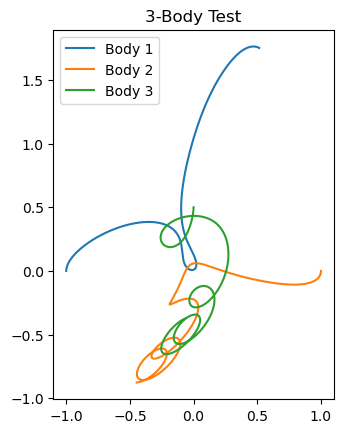

In [ ]:
G = 1.0
time = 0.0002
steps = 20000

b1 = CelestialBodies(
    r=np.array([-1.0, 0.0, 0.0]),
    v=np.array([0.0,  0.3, 0.0]),
    m=1.0
)

b2 = CelestialBodies(
    r=np.array([ 1.0, 0.0, 0.0]),
    v=np.array([0.0, -0.3, 0.0]),
    m=1.0
)

b3 = CelestialBodies(
    r=np.array([0.0, 0.5, 0.0]),
    v=np.array([0.0, 0.0, 0.0]),
    m=1.0
)

x1, y1 = [], []
x2, y2 = [], []
x3, y3 = [], []

for _ in range(steps):
     # --- phase 1: acceleration at t ---
    b1.Force(b2, b3); a1_old = b1.f / b1.m
    b2.Force(b1, b3); a2_old = b2.f / b2.m
    b3.Force(b1, b2); a3_old = b3.f / b3.m

    # --- phase 2: position update ---
    b1.r += b1.v*time + 0.5*a1_old*time**2
    b2.r += b2.v*time + 0.5*a2_old*time**2
    b3.r += b3.v*time + 0.5*a3_old*time**2

    x1.append(b1.r[0]); y1.append(b1.r[1])
    x2.append(b2.r[0]); y2.append(b2.r[1])
    x3.append(b3.r[0]); y3.append(b3.r[1])

    # --- phase 3: acceleration at t + dt ---
    b1.Force(b2, b3); a1_new = b1.f / b1.m
    b2.Force(b1, b3); a2_new = b2.f / b2.m
    b3.Force(b1, b2); a3_new = b3.f / b3.m

    # --- phase 4: velocity update ---
    b1.v += 0.5*(a1_old + a1_new)*time
    b2.v += 0.5*(a2_old + a2_new)*time
    b3.v += 0.5*(a3_old + a3_new)*time

    #origin testing 
    if _ % 1000 == 0:
        total_mass = b1.m + b2.m + b3.m
        com = (b1.m*b1.r + b2.m*b2.r + b3.m*b3.r) / total_mass
        print(f"Drift from origin: {np.linalg.norm(com)}")



import matplotlib.pyplot as plt

plt.plot(x1, y1, label="Body 1")
plt.plot(x2, y2, label="Body 2")
plt.plot(x3, y3, label="Body 3")

plt.legend()
plt.gca().set_aspect('equal')
plt.title("3-Body Test")
plt.show()



